In [1]:
import re
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from unidecode import unidecode
from scipy.stats import zscore

CHANNELS_PATH = '../data/cleaned/cleaned_channels_info.csv'
VIDEOS_PATH = '../data/cleaned/cleaned_videos_info.csv'
COMMENTS_PATH = '../data/cleaned/cleaned_comments_info.csv'

stopwords_pt = stopwords.words('portuguese')
custom_stopwords = [
    'pra', 'pro', 'vc', 'vcs', 'to', 'ta', 'ne', 'tb', 'tbm',
    'entao', 'assim', 'ainda', 'cada', 'toda', 'tudo', 'todo',
    'aqui', 'hoje', 'agora', 'sempre', 'nunca',
    'kkk', 'amem',
    'mim', 'bem', 'bom', 'vai', 'vou', 'faz', 'fazer',
    'pode',
    'deus', 'jesus', 'senhor', 'gloria',
    'boa', 'noite', 'obrigado', 'obrigada',
]
stopwords_pt = list(set(stopwords.words('portuguese')) | set(custom_stopwords))

COMMON_MEDICATIONS = [
    "fluoxetina",
    "sertralina",
    "escitalopram",
    "paroxetina",
    "venlafaxina",
    "desvenlafaxina",
    "duloxetina",
    "amitriptilina",
    "bupropiona",
    "mirtazapina",
    "trazodona",
    "clonazepam",
    "alprazolam",
    "zolpidem",
    "quetiapina",
    "risperidona",
    "aripiprazol",
    "lítio",
    "metilfenidato",
    "lisdexanfetamina",
]

CONDITION_GROUPS = {
    "Ansiedade": ["ansiedade", "panico", "tag", "fobia social", "nervoso", "estresse", "calmante"],
    "Depressão": ["depressao", "tristeza", "desanim", "angustia", "melancolia", "antidepressivo"],
    "Insônia": ["insonia", "dormir", "sonifero", "indutor do sono", "acordar menos"],
    "TDAH": ["tdah", "deficit de atencao", "concentracao", "foco", "estudar"],
    "Bipolaridade": ["bipolar", "bipolaridade", "mania", "oscilacao de humor", "altos e baixos"],
    "Dor_Cronica": ["dor cronica", "fibromialgia", "neuropatica", "dor nos nervos"],
    "Compulsão_Alimentar": ["compulsao alimentar", "fome emocional", "emagrecer", "perder peso"]
}

MEDICATION_GROUPS = {
    "ISRS": [
        "Fluoxetina", "Prozac", "Daforin", "Fluxene", "Verotina", "Sertralina", "Zoloft", "Tolrest",
        "Afetus", "Dieloft", "Paroxetina", "Paxil", "Pondera", "Roxetin", "Paxtrat", "Cebrilin",
        "Citalopram", "Cipramil", "Procimax", "Città", "Alcytam", "Maxapram", "Denyl", "Escitalopram",
        "Lexapro", "Esc ODT", "Reconter", "Espran", "Fluvoxamina", "Luvox", "Revoc"
    ],

    "ISRSN": [
        "Venlafaxina", "Efexor XR", "Venlaxin", "Venlifit OD", "Vensate", "Desvenlafaxina", "Pristiq",
        "Elifore", "Desve", "Zodel", "Imense", "Deller", "Desduo", "Duloxetina", "Cymbalta", "Velija",
        "Cymbi", "Leduo"
    ],

    "Tricíclicos": [
        "Amitriptilina", "Tryptanol", "Amytril", "Clomipramina", "Anafranil", "Imipramina", "Tofranil",
        "Nortriptilina", "Pamelor", "Nortril", "Doxepina", "Aponal", "Sinequan"
    ],

    "Tetracíclicos": [
        "Mirtazapina", "Remeron", "Remeron Soltab", "Menelat", "Razapina", "Mianserina", "Tolvon",
        "Maprotilina", "Ludiomil", "Menelat ODT", "Razapina ODT"
    ],

    "IMAO": [
        "Tranilcipromina", "Parnate", "Sulpan", "Moclobemida", "Aurorix", "Selegilina", "Eldepryl"
    ],

    "Antidepressivos_atípicos": [
        "Bupropiona", "Contrave", "Wellbutrin", "Zyban", "Bup", "Bupium", "Alpes XL", "Trazodona", "Donaren",
        "Loredon",  "Reboxetina", "Prolift", "Agomelatina", "Valdoxan", "Vortioxetina", "Brintellix", "Trintellix", 
    ],

    "Adjuvantes_depressivos": [
        "Alprazolam", "Tranquinal", "Xanax", "Clonazepam", "Rivotril", "Clopam", "Clonotril", "Diazepam", "Valium", "Dienpax",
        "Bromazepam", "Lexotan", "Somalium", "Lorazepam", "Lorax", "Zolpidem", "Stilnox", "Zopiclona", "Imovane", "Melatonina",
        "Midazolam", "Dormonid", "Flunitrazepam", "Rohypnol", "Rohydorm", "Flurazepam", "Dalmadorm", "Estazolam", "Noctal",
    ],

    "Adjuvantes_antipsicóticos": [
        "Aripiprazol", "Abilify", "Aristab", "Aipri", "Toarip", "Biquiz", "Quetiapina", "Seroquel", "Quet", "Kitapen", "Quetros",
        "Quetipin", "Quepsia", "Tracox", "Seroquel XRO", "Quet XR", "Atip XR", "Olanzapina", "Zyprexa", "Axonium",
        "Onaz", "Crisapina", "Clozapina", "Leponex", "Pinazan", "Okótico", "Brexpiprazol", "Rexulti", "Carbolitium",
        "Carlit", "Bilyt",  "Triiodotironina", "Modafinila", "Stavigile",
    ],

    "Anticonvulsivantes_e_Estabilizadores": [
        "Ácido Valpróico", "Depakote", "Epilenil", "Torval CR", "Vodsso", "Valproáto de sódio", "Depakene", "Valpakine",
        "Carbamazepina", "Tegretol", "Tegretol CR", "Oxcarbazepina", "Trileptal", "Oxcarb", "Topiramato", "Topamax",
        "Toptil", "Tempora", "Vidmax", "Topit", "Arasid", "Pregabalina", "Lyrica", "Dorene", "Insit", "Konduz", "Prebictal"
    ],

    "TDAH_e_Estimulantes": [
        "Metilfenidato", "Ritalina", "Concerta", "Ritalina LA", "Ragione", "Attenze", "Medato",
        "Lisdexanfetamina", "Venvanse", "Juneve", "Lyberdia", "Lind", "Lisvenx", "Lisdev",
        "Atomoxetina", "Attentah", "Modafinila", "Stavigile"
    ],

    "Antipsicóticos_Outros": [
        "Haloperidol", "Haldol", "haldol decanoato", "Risperidona", "Risperdal", "Riss", "Respidon", "Risperidon",
        "Viverdal", "Zargus", "Perlid", "Rispalum", "Risperdal Consta", "Ziprasidona", "Geodon", "Sulpirida",
        "Equilid", "Dogmatil", "Amissulprida", "Socian", "Zuclopentixol", "Clopixol", "Clopixol Depot",
        "Clopixol Acuphase", "Flufenazina", "Anatensol", "Lurasidona", "Latuda", "Lutab"
    ]
}

In [2]:
def clean_text(text):
    text = text.lower()
    text = unidecode(text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# preprocess the medication and condition lists to ensure consistency in text processing
COMMON_MEDICATIONS = [clean_text(med) for med in COMMON_MEDICATIONS]
MEDICATION_GROUPS = {
    group: [clean_text(med) for med in meds]
    for group, meds in MEDICATION_GROUPS.items()
}
CONDITION_GROUPS = {
    group: [clean_text(cond) for cond in conds]
    for group, conds in CONDITION_GROUPS.items()
}

In [3]:
def clean_comments(comments: pd.Series) -> pd.Series:
    text = comments.fillna('').astype(str)
    text = text.str.lower()
    text = text.str.replace(r'http\S+|www\.\S+', '', regex=True)
    text = text.str.replace(r'\d+', '', regex=True)             # <--
    text = text.str.replace(r'@\w+', '', regex=True)
    text = text.apply(lambda x: re.sub(r'(.)\1{2,}', r'\1\1\1', x))
    text = text.apply(lambda x: unicodedata.normalize('NFKD', x)
                      .encode('ascii', 'ignore')
                      .decode('utf-8'))
    text = text.str.replace(r'\s+', ' ', regex=True).str.strip()
    
    return text
    
def plot_wordcloud(texts: str, title: str='', save_path: str=''):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords_pt,
        min_word_length=3,
        collocations=False,
        random_state=42
    ).generate(texts)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    
    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)

    plt.show()

def plot_ngram_wordcloud(texts: list[str], title: str='', save_path: str='', ngram_range: tuple=(2, 2)):        
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words=stopwords_pt
    )

    X = vectorizer.fit_transform(texts)

    frequencies = dict(
        zip(
            vectorizer.get_feature_names_out(),
            X.sum(axis=0).A1
        )
    )
    
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        random_state=42
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    
    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)

    plt.show()

def plot_cdf(data: pd.DataFrame, x: str, xlabel: str='', ylabel: str='CDF', save_path: str=''):
    plt.figure(figsize=(4, 3))

    sns.ecdfplot(data, x=x)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)
    
    plt.show()

def plot_bar(data: pd.DataFrame, x: str, y: str, xlabel='', ylabel='', save_path: str=''):
    plt.figure(figsize=(6, 4))

    sns.barplot(data, x=x, y=y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)

    plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

def plot_heatmap(data: pd.DataFrame, group_col: list, x: str, y: str, save_path: str='', time_window: str='year'):
    data = data.copy()
    
    if time_window == 'year':
        data['period'] = data['published_at'].dt.year.astype(str)
    elif time_window == 'month':
        data['period'] = data['published_at'].dt.month.astype(int)
    data_grouped = data.groupby('period').agg({col: 'sum' for col in group_col}).reset_index()

    # transpose the DataFrame to have periods as columns and medication groups as rows
    data_transposed = data_grouped.set_index('period')[group_col].T

    # clean the row names
    new_cols = {
        col: col.replace('_mentioned_group', '').replace('_mentioned_condition', '').replace('_mentioned', '').replace('_', ' ').strip() 
        for col in group_col
    }
    data_transposed = data_transposed.rename(index=new_cols)

    # zscore normalization across rows
    row_mean = data_transposed.mean(axis=1)
    row_std = data_transposed.std(axis=1, ddof=0).replace(0, 1)
    data_zscore = data_transposed.sub(row_mean, axis=0).div(row_std, axis=0)

    plt.figure(figsize=(10, 6))
    
    sns.heatmap(
        data_zscore, 
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm', 
        center=0,
        cbar=True, 
        cbar_kws={'label': 'Z-Score'}
    )
    
    plt.xlabel(x)
    plt.ylabel(y)
    
    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)
        
    plt.show()

### Videos

In [4]:
df_videos = pd.read_csv(VIDEOS_PATH)
df_comments = pd.read_csv(COMMENTS_PATH, parse_dates=['published_at'])
df_comments['comment'] = clean_comments(df_comments['comment'])

df_comments = df_comments.merge(
    df_videos[['video_id', 'title']],
    on='video_id',
    how='left'
)
df_comments.head()

,video_id,comment_id,author_profile_image_url,author_channel_url,author_channel_id,comment,published_at,like_count,is_reply,parent_id,channel_id,title
0,o4rkslboNS4,UgyWGRwVmS9ETp7-0Dl4AaABAg.9mtzszJepKGANMNqrD8zJY,https://yt3.ggpht.com/ytc/AIdro_n0dcFEAYEKbOA1...,http://www.youtube.com/@brunairenetavares1725,UCgJY3oNzciQCyu4g5_mBnGA,meu deus. nao sei se o litio sozinho e capaz d...,2025-09-22 00:00:52,3,True,UgyWGRwVmS9ETp7-0Dl4AaABAg,UCPSF_i4TthY5-7XMnLjh2jQ,Quais os EFEITOS colaterais do Carbolitium? Al...
1,wuITgBgykyY,UgzRdClas81p1tcdnC54AaABAg,https://yt3.ggpht.com/jQ8Gi1mki74JxEjtDkWePsCB...,http://www.youtube.com/@monlachest,UCrCJ8b4yQyJk5RTmoKrdI6Q,gente me ajudem por favor eu tenho tdah so iss...,2025-02-02 17:22:54,0,False,NaN,UCPSF_i4TthY5-7XMnLjh2jQ,Para que serve o DEPAKOTE e como o remédio FUN...
2,KCpVXQ4KHVA,UgzTH7MSqJyoK-mUBV54AaABAg.9Q19ctERq-y9Vpw6eTgfjt,https://yt3.ggpht.com/ATRhbLxd99n6Do3G3N8PLX81...,http://www.youtube.com/@MundodaMenteCanal,UCTr2YJzb3SispJqg7wT2fcg,pode ajudar sim,2021-12-11 23:28:08,1,True,UgzTH7MSqJyoK-mUBV54AaABAg,UCPSF_i4TthY5-7XMnLjh2jQ,"Alerta sobre a Fluoxetina, Cuidados e Efeitos ..."
3,KiedaOFShRI,UgzEPsHjd7-BAjQ-DU54AaABAg,https://yt3.ggpht.com/ytc/AIdro_lXvXqut5kGOmNb...,http://www.youtube.com/@elianenatividade4215,UCEplK3ZSht-XDAP5LUuJXLA,"nao tenho diabetes, nem insuficiencia renal, n...",2025-07-01 11:15:20,0,False,NaN,UC07ssbQK-E2hiKkhaVAP7BQ,7 HÁBITOS ANTES DE DORMIR QUE CAUSAM AVC e INF...
4,FyxVePa6zNA,UgyaZsukykeWRyOyxcV4AaABAg,https://yt3.ggpht.com/ytc/AIdro_lQP04o0156tOjg...,http://www.youtube.com/@LucasSantos-gl4ls,UC6_0WB86FxCFNaZlS7zOEgQ,estou na minha quarta semana tomando atentah e...,2024-02-20 12:01:19,2,False,NaN,UCl-YsxVqaLDn-NnSXkqp0Qg,Atomoxetina para o TDAH. Vale a pena?


In [5]:
df_comments['title'] = df_comments['title'].str.lower()
texts_title_wordcloud = ' '.join(df_comments['title'])

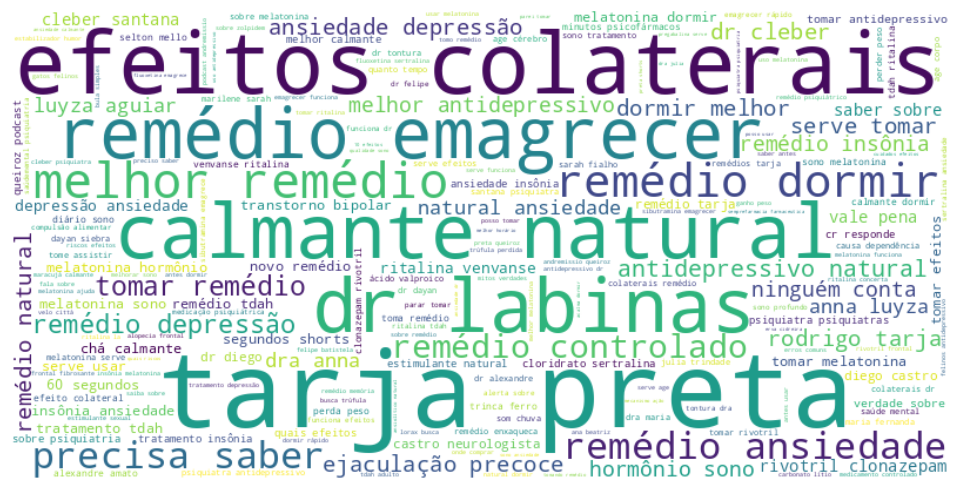

In [6]:
texts_title_bigram = df_videos['title'].tolist()
plot_ngram_wordcloud(texts_title_bigram, save_path='../figs/initial_analysis/title_bigram.png')

### Comments

In [7]:
df_comments_engaged_users = (
    df_comments[df_comments['author_channel_id'].duplicated(keep=False)]
    .groupby('author_channel_id')
    .agg(
        first_comment=('published_at', 'min'),
        last_comment=('published_at', 'max')
    )
)

# diff between first and last comment
df_comments_engaged_users['time_window_users'] = (
    df_comments_engaged_users['last_comment']
    - df_comments_engaged_users['first_comment']
)

# number of days
df_comments_engaged_users['days'] = (
    df_comments_engaged_users['time_window_users']
    .dt.total_seconds() / 86400
)
df_comments_engaged_users.shape

(127110, 4)

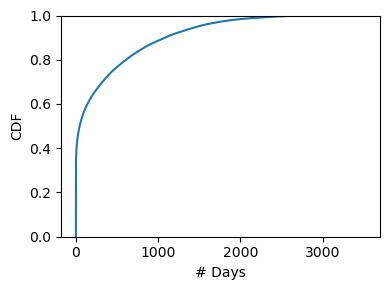

In [8]:
plot_cdf(data=df_comments_engaged_users, x='days', xlabel='# Days', save_path='../figs/initial_analysis/days_user_retention.png')

In [9]:
df_comments['hour'] = df_comments['published_at'].dt.hour

comments_by_hour = (
    df_comments.groupby('hour')
    .size()
    .reset_index(name='num_comments')
)

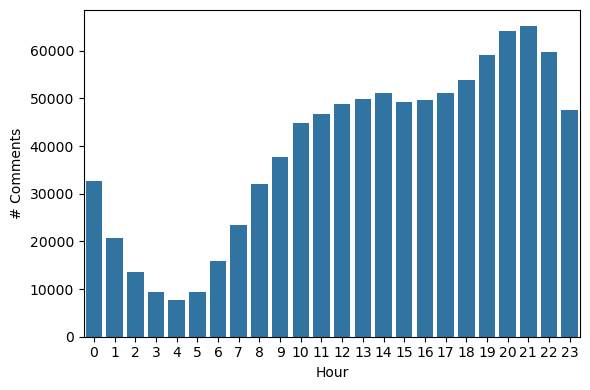

In [10]:
plot_bar(comments_by_hour, x='hour', y='num_comments', xlabel='Hour', ylabel='# Comments', save_path='../figs/initial_analysis/num_comments_by_hour.png')

In [11]:
df_comments_night = df_comments[
    (df_comments['published_at'].dt.hour >= 0) &
    (df_comments['published_at'].dt.hour <= 3)
]
df_comments_night.shape

(76361, 13)

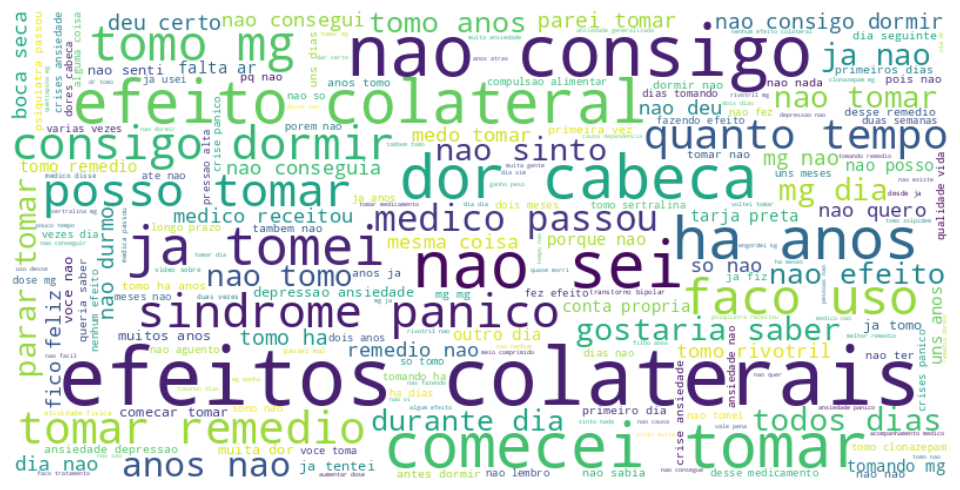

In [12]:
text_comment_night_bigram = df_comments_night['comment'].tolist()
plot_ngram_wordcloud(text_comment_night_bigram, save_path='../figs/initial_analysis/ngram_nightime_comments.png', ngram_range=(2, 3))

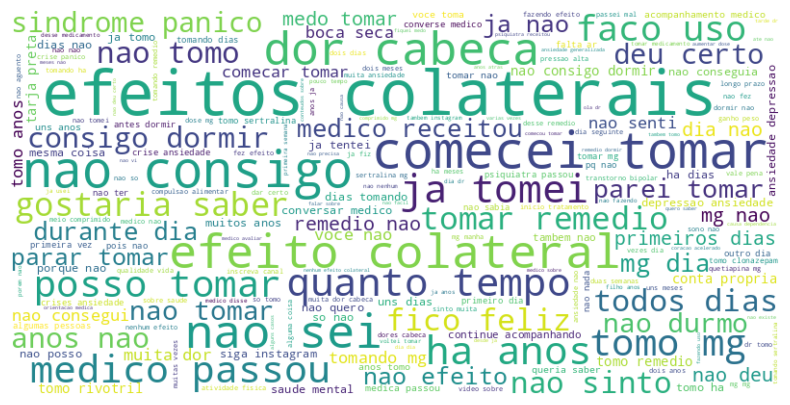

In [13]:
df_comments_overall = df_comments[~df_comments['comment_id'].isin(df_comments_night['comment_id'])]
text_comment_overall = df_comments_overall['comment'].tolist()
plot_ngram_wordcloud(text_comment_overall, ngram_range=(2, 3))

In [14]:
for group, medications in MEDICATION_GROUPS.items():
    regex_groups = '|'.join([f'\\b{med}\\b' for med in medications])
    df_comments[f'{group}_mentioned_group'] = df_comments['comment'].str.contains(regex_groups, case=False, regex=True)
group_cols = [col for col in df_comments.columns if col.endswith('_mentioned_group')]
group_total_mentions = df_comments[group_cols].sum().sort_values(ascending=False)

for med in COMMON_MEDICATIONS:
    df_comments[f'{med}_mentioned'] = df_comments['comment'].str.contains(f'\\b{med}\\b', case=False, regex=True)
med_cols = [col for col in df_comments.columns if col.endswith('_mentioned')]
med_total_mentions = df_comments[med_cols].sum().sort_values(ascending=False)

for cond in CONDITION_GROUPS.keys():
    regex_groups = '|'.join([f'\\b{cond}\\b' for cond in CONDITION_GROUPS[cond]])
    df_comments[f'{cond}_mentioned_condition'] = df_comments['comment'].str.contains(regex_groups, case=False, regex=True)
condition_cols = [col for col in df_comments.columns if col.endswith('_mentioned_condition')]

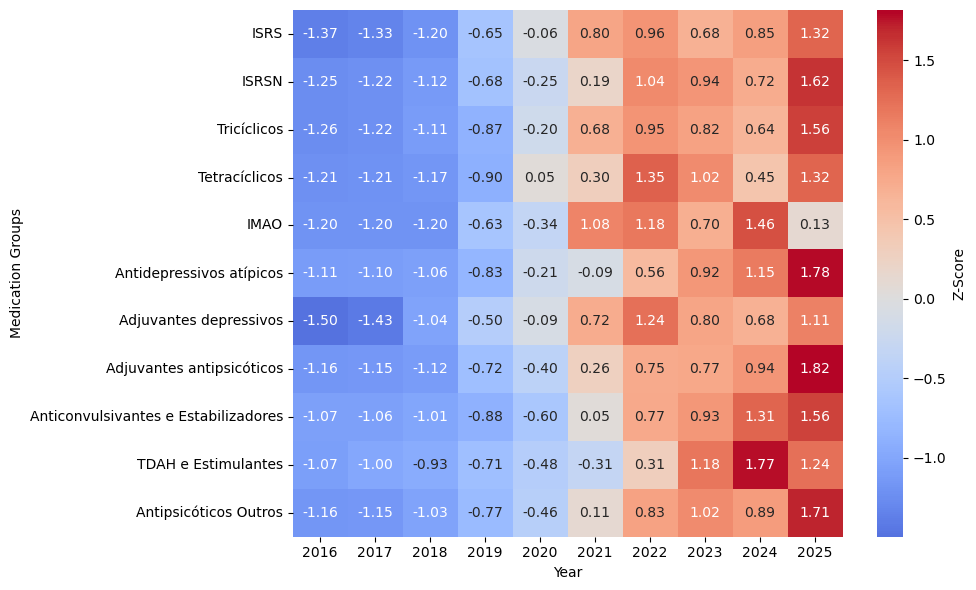

In [15]:
plot_heatmap(df_comments, group_cols, x='Year', y='Medication Groups', save_path='../figs/initial_analysis/medication_groups_heatmap.png')

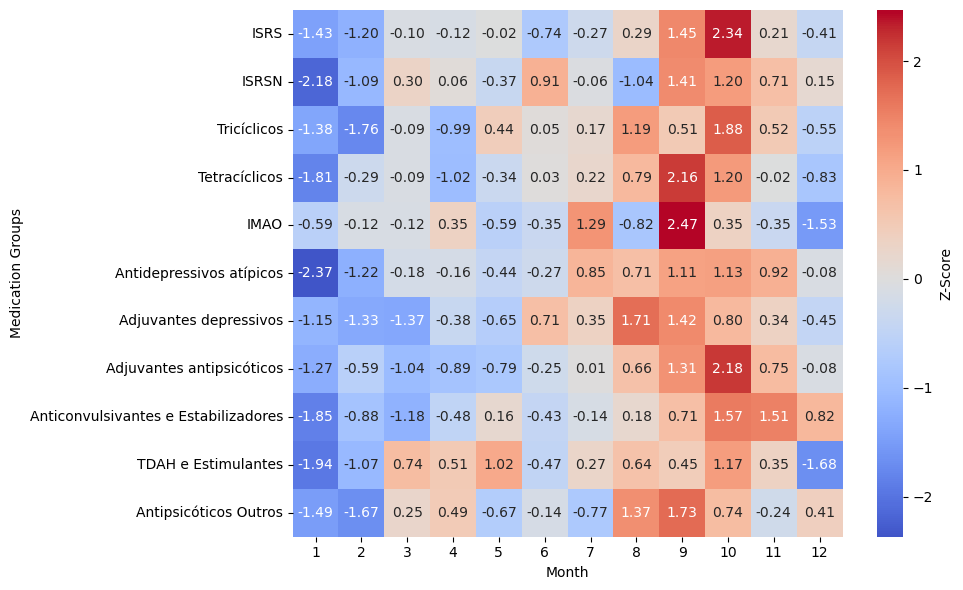

In [16]:
plot_heatmap(df_comments, group_cols, x='Month', y='Medication Groups', save_path='../figs/initial_analysis/medication_groups_heatmap_month.png', time_window='month')

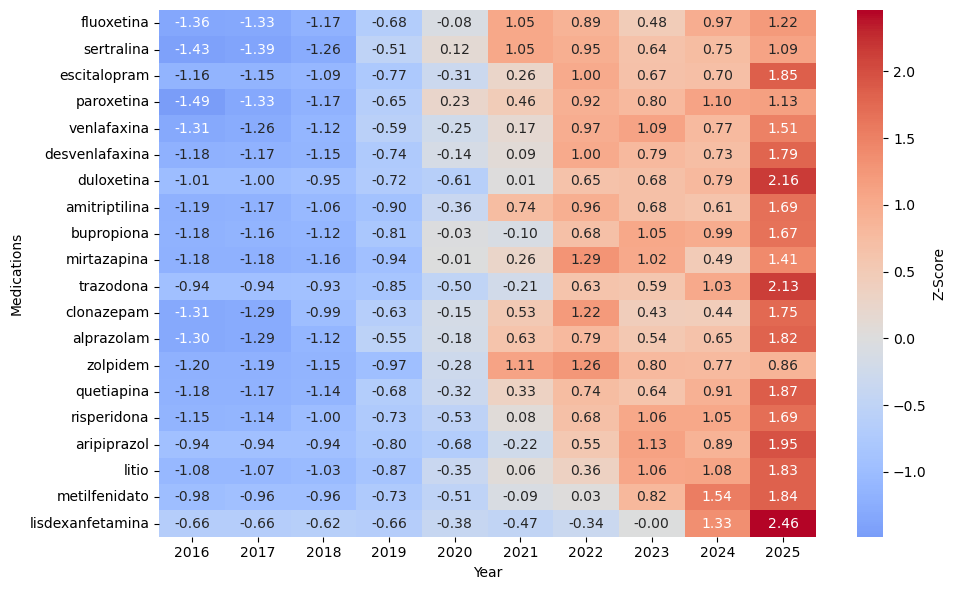

In [17]:
plot_heatmap(df_comments, med_cols, x='Year', y='Medications', save_path='../figs/initial_analysis/medications_heatmap.png')

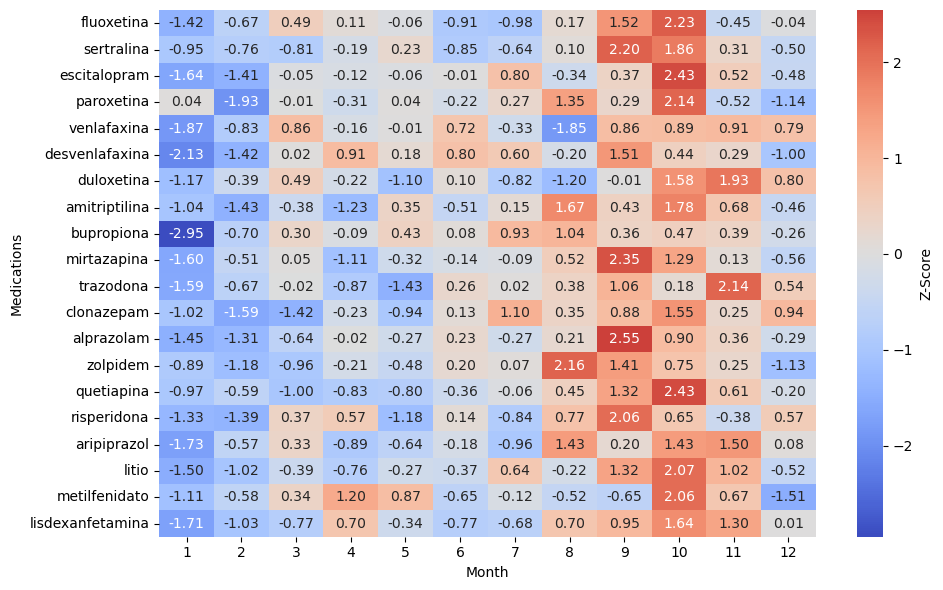

In [18]:
plot_heatmap(df_comments, med_cols, x='Month', y='Medications', save_path='../figs/initial_analysis/medications_heatmap_month.png', time_window='month') 

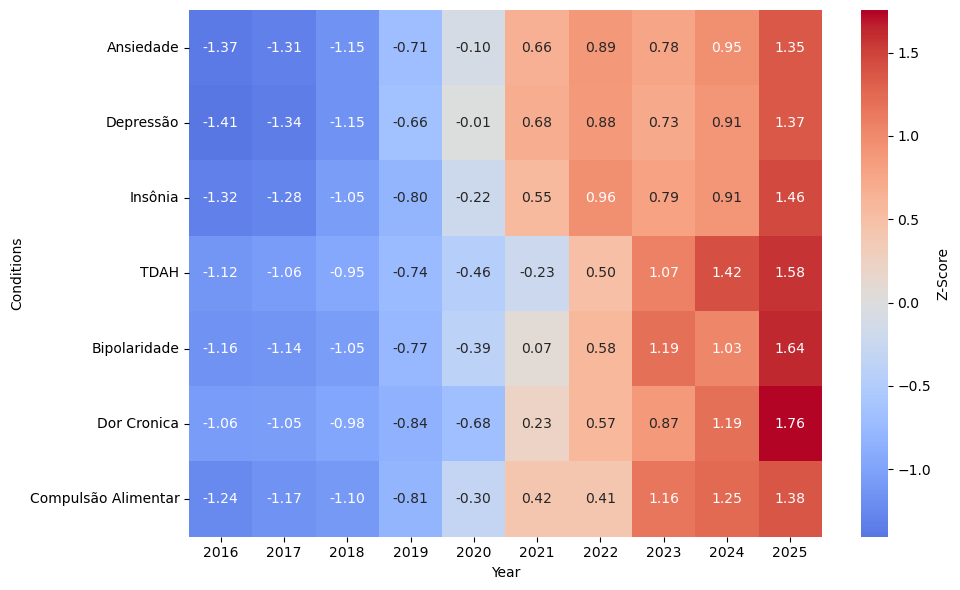

In [19]:
plot_heatmap(df_comments, condition_cols, x='Year', y='Conditions', save_path='../figs/initial_analysis/conditions_heatmap.png')

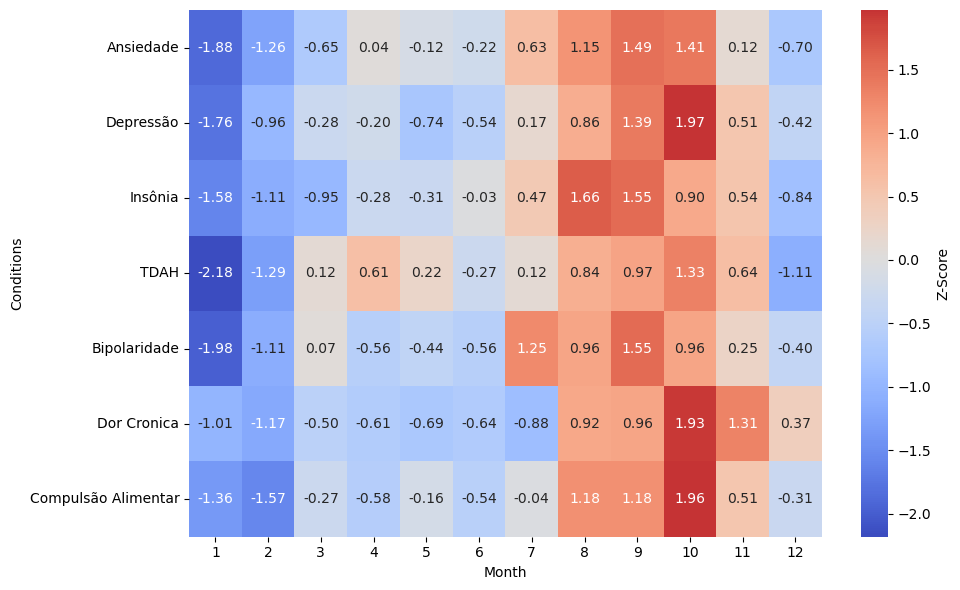

In [20]:
plot_heatmap(df_comments, condition_cols, x='Month', y='Conditions', save_path='../figs/initial_analysis/conditions_heatmap_month.png', time_window='month')